# Doprinos 8 — Automatski izbor optimalne Faster-Whisper konfiguracije

## Cilj eksperimenta

Cilj ovog integracionog eksperimenta je da se na osnovu rezultata prethodnih eksperimenata automatski odredi Faster-Whisper konfiguracija koja predstavlja odgovarajući kompromis između:

* **tačnosti transkripcije — WER**,
* **brzine izvršavanja — RTF**,
* **memorijske zahtevnosti — RAM**.

Za izbor osnovne kombinacije **model + kvantizacija** koristi se homogen benchmark iz Doprinos 5, koji obuhvata svih **40 prirodnih srpskih audio zapisa** za svih osam kombinacija modela `tiny`, `base`, `small` i `medium` sa `INT8` i `FLOAT32` kvantizacijom.

Ukupno se zato poredi **8 konfiguracija × 40 snimaka = 320 transkripcija**.

WER se u ovom notebook-u ponovo izračunava iz već sačuvanih transkripata i referentnih tekstova, dok se RTF i memorijski rezultati preuzimaju iz prethodno izvršenih eksperimenata. Time se izbegava nepotrebno ponovno pokretanje sooljno izabranog skupa pondera.



In [1]:
from pathlib import Path
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from jiwer import wer

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [2]:
# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

REZULTATI_ROOT = PROJECT_ROOT / "rezultati"
OUT_DIR = REZULTATI_ROOT / "08_automatski_izbor_optimalne_konfiguracije"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PATH_05_ALL = REZULTATI_ROOT / "05_kvantizacija_latencija_rtf" / "05_svi_rezultati.csv"
PATH_05_RAM = REZULTATI_ROOT / "05_kvantizacija_latencija_rtf" / "05_model_load_ram.csv"

PATH_04 = REZULTATI_ROOT / "04_uticaj_beam_searcha" / "04_beam_rezime.csv"
PATH_06 = REZULTATI_ROOT / "06_uticaj_vad_filtera" / "06_vad_agregatni_rezultati.csv"
PATH_07 = REZULTATI_ROOT / "07_streaming_chunking_real_time" / "07_chunking_finalni_rezime.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)


PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
OUT_DIR: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\08_automatski_izbor_optimalne_konfiguracije


In [3]:
REFERENCE = {1: 'Veštačka inteligencija omogućava računarima da rešavaju složene probleme i analiziraju velike količine podataka.', 2: 'Automatsko prepoznavanje govora pretvara izgovorene reči u tekst koji računar može dalje da obrađuje.', 3: 'Danas je veoma prijatan dan, pa smo odlučili da prošetamo kroz centar grada posle ručka.', 4: 'Novi računari imaju brže procesore, više memorije i znatno bolje performanse nego prethodne generacije.', 5: 'Mašinsko učenje koristi podatke kako bi model naučio da prepoznaje obrasce i donosi odgovarajuće odluke.', 6: 'Sutra ujutru moram da završim nekoliko obaveza, a zatim planiram da se vidim sa prijateljima.', 7: 'Kvalitet zvučnog zapisa može značajno da utiče na tačnost sistema za automatsko prepoznavanje govora.', 8: 'Temperatura je tokom noći naglo pala, ali se očekuje da će sutra vreme ponovo biti toplije.', 9: 'Neuronske mreže danas se koriste za obradu slike, teksta, zvuka i mnogih drugih vrsta podataka.', 10: 'Dobar sistem mora istovremeno da bude dovoljno brz, precizan i pouzdan u različitim uslovima.', 11: 'Savremeni sistemi za automatsko prepoznavanje govora koriste duboke neuronske mreže kako bi analizirali zvučni signal i pretvorili ga u tekst. Njihova tačnost zavisi od modela, kvaliteta snimka, jezika i karakteristika govornika.', 12: 'Juče sam krenuo do grada nešto ranije nego obično. Na ulicama nije bilo mnogo ljudi, pa sam brzo završio sve obaveze. Nakon toga sam seo u obližnji kafić i sačekao prijatelja.', 13: 'Whisper je model za automatsko prepoznavanje govora koji može da radi sa velikim brojem jezika. Faster-Whisper koristi optimizovanu implementaciju koja omogućava efikasnije izvršavanje i manju potrošnju računarskih resursa.', 14: 'Kada razgovaramo u tihoj prostoriji, sistem uglavnom može veoma jasno da prepozna izgovorene reči. Međutim, saobraćaj, muzika, razgovor drugih ljudi i različiti izvori šuma mogu značajno da otežaju transkripciju.', 15: 'Tokom razvoja softverske aplikacije programeri prvo analiziraju zahteve korisnika, zatim projektuju sistem i implementiraju potrebne funkcionalnosti. Nakon toga slede testiranje, ispravljanje grešaka i postavljanje aplikacije u produkciono okruženje.', 16: 'Prošlog vikenda smo odlučili da provedemo dan u prirodi. Vreme je bilo sunčano i prijatno, pa smo poneli hranu i nekoliko stvari koje su nam bile potrebne. Vratili smo se kući tek predveče.', 17: 'Veći modeli mašinskog učenja često mogu da postignu veću tačnost, ali zahtevaju više memorije i procesorske snage. Zbog toga najveći model nije uvek najbolji izbor za praktičnu primenu.', 18: 'Brzina automatskog prepoznavanja govora posebno je važna kod aplikacija koje rade u realnom vremenu. Korisnik očekuje da sistem reaguje brzo i da se transkript pojavljuje bez primetnog kašnjenja.', 19: 'Kada sam jutros uključio računar, prvo sam proverio elektronsku poštu i poruke. Posle toga sam otvorio projekat na kojem trenutno radim i nastavio implementaciju funkcionalnosti koju sam započeo prethodnog dana.', 20: 'Srpski jezik sadrži glasove i karaktere koji se razlikuju od engleskog jezika. Zbog toga je interesantno analizirati koliko dobro isti model prepoznaje govor na različitim jezicima.', 21: 'Kvantizacija omogućava da se neuronski model izvršava korišćenjem manje preciznih numeričkih formata. Na taj način moguće je smanjiti potrošnju memorije i ubrzati izvršavanje uz prihvatljivu promenu tačnosti.', 22: 'Čovek tokom običnog razgovora često pravi kratke pauze, menja brzinu govora ili zastane kako bi razmislio. Sistem za prepoznavanje govora mora da bude dovoljno robustan da pravilno obradi takve situacije.', 23: 'Danas postoji veliki broj aplikacija koje koriste veštačku inteligenciju. Ona se primenjuje u medicini, industriji, obrazovanju, saobraćaju, finansijama i mnogim svakodnevnim digitalnim servisima.', 24: 'Kada se zvučnom signalu doda šum, neke reči postaju teže razumljive. Što je nivo šuma veći u odnosu na govor, sistemu je teže da napravi tačnu transkripciju celog snimka.', 25: 'Pre nego što rezultate eksperimenta možemo pravilno da uporedimo, potrebno je koristiti iste ulazne podatke i jasno definisane metrike. Na taj način razlika u rezultatima može da se poveže sa promenom koju zapravo ispitujemo.', 26: 'Automatsko prepoznavanje govora predstavlja oblast veštačke inteligencije koja se bavi pretvaranjem zvučnog signala u tekst. Savremeni sistemi koriste modele dubokog učenja koji mogu da analiziraju kompleksne karakteristike ljudskog govora. Njihove performanse mogu da zavise od jezika, kvaliteta mikrofona, prisustva pozadinskog šuma, brzine govora i karakteristika samog govornika. Zbog toga je prilikom evaluacije važno koristiti različite vrste zvučnih zapisa.', 27: 'Jednog jutra krenuo sam automobilom prema gradu nešto ranije nego obično. Saobraćaj je u početku bio veoma slab, ali se približavanjem centru broj vozila postepeno povećavao. Dok sam čekao na semaforu, na radiju su govorili o vremenskoj prognozi za narednih nekoliko dana. Najavljeno je sunčano vreme, ali i mogućnost kratkotrajne kiše tokom vikenda. Kada sam stigao, parkirao sam automobil i nastavio pešice.', 28: 'Whisper postoji u više veličina modela, od veoma malih do znatno većih modela. Manji modeli zahtevaju manje memorije i uglavnom omogućavaju bržu transkripciju, dok veći modeli mogu da pruže veću tačnost u zahtevnijim uslovima. Zbog toga izbor modela predstavlja kompromis između kvaliteta transkripcije i potrebnih računarskih resursa. Taj kompromis je posebno važan kada se sistem izvršava na običnom računaru bez snažne grafičke kartice.', 29: 'Pozadinski šum predstavlja jedan od najčešćih problema kod sistema za automatsko prepoznavanje govora. U realnom okruženju mikrofon ne snima samo glas osobe već i zvuk automobila, ventilatora, drugih ljudi ili muzike. Ako je govor dovoljno snažan u odnosu na šum, transkripcija može ostati veoma dobra. Međutim, kada se odnos signala i šuma smanjuje, broj pogrešno prepoznatih reči uglavnom počinje da raste.', 30: 'Kada razvijamo sistem koji treba da radi u realnom vremenu, nije dovoljno posmatrati samo njegovu tačnost. Potrebno je analizirati koliko vremena modelu treba da obradi određenu količinu zvuka. Ako obrada pet sekundi govora traje kraće od pet sekundi, sistem potencijalno može da prati govor bez stalnog povećavanja kašnjenja. Zbog toga su latencija i faktor realnog vremena veoma korisne metrike prilikom evaluacije ovakvih sistema.', 31: 'Pre nekoliko dana organizovali smo malo okupljanje sa prijateljima. Dogovor je bio da se svi nađemo oko šest sati, ali je nekoliko ljudi kasnilo zbog saobraćaja. Dok smo ih čekali, razgovarali smo o poslu, putovanjima i planovima za naredne mesece. Kasnije smo naručili večeru i ostali zajedno nekoliko sati. Iako ništa posebno nije bilo planirano, veče je na kraju bilo veoma zanimljivo i prijatno.', 32: 'Ljudski govor nije potpuno konstantan signal. Neko govori brzo, neko sporije, a pojedini govornici prave veoma duge pauze između rečenica. Razlikuju se i visina glasa, naglasak, način izgovora i jačina govora. Sistem koji postiže odlične rezultate kod jednog govornika zato ne mora nužno da postigne iste rezultate kod druge osobe. Korišćenje više govornika omogućava realniju procenu sposobnosti modela da generalizuje.', 33: 'Voice Activity Detection koristi se za razlikovanje delova zvučnog zapisa u kojima postoji govor od delova u kojima se nalazi tišina. Ako snimak sadrži duge periode bez govora, njihovo uklanjanje može da smanji količinu podataka koju model mora da obradi. Međutim, algoritam mora pažljivo da odredi početak i kraj govora, jer previše agresivno uklanjanje može da odseče deo izgovorene reči i tako negativno utiče na transkripciju.', 34: 'Beam search predstavlja jedan od načina pronalaženja verovatne sekvence reči tokom dekodiranja rezultata modela. Veća vrednost parametra omogućava razmatranje većeg broja mogućih kandidata, ali istovremeno može da poveća vreme potrebno za obradu. Zbog toga je korisno eksperimentalno proveriti da li povećanje beam size parametra zaista donosi značajno poboljšanje tačnosti i koliko dodatnih računarskih resursa zahteva.', 35: 'Prilikom izvođenja eksperimenta veoma je važno menjati jednu karakteristiku sistema dok ostali uslovi ostaju isti. Ako istovremeno promenimo model, jezik, kvalitet zvuka i parametre dekodiranja, teško možemo da zaključimo zbog čega je rezultat postao bolji ili lošiji. Kontrolisani eksperimenti omogućavaju jasnije poređenje različitih konfiguracija i daju pouzdaniju osnovu za izvođenje zaključaka o ponašanju sistema.', 36: 'Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu.', 37: 'Kada govorimo o performansama modela za prepoznavanje govora, postoje dve različite stvari koje želimo da postignemo. Prva je što tačniji transkript, a druga što efikasnije izvršavanje. Veći model može bolje da prepozna komplikovane rečenice ili govor u težim uslovima, ali istovremeno može zahtevati mnogo više memorije i vremena. Manji model može biti nešto manje precizan, ali dovoljno brz da se koristi na običnom laptopu. Kvantizacija predstavlja još jedan način optimizacije jer omogućava korišćenje numeričkog formata manje preciznosti. Time se može smanjiti količina potrebne memorije i ubrzati obrada. Međutim, svaka optimizacija mora da bude eksperimentalno proverena. Nije dovoljno pokazati da je jedna konfiguracija brža. Potrebno je proveriti i da li je njena tačnost ostala prihvatljiva. Upravo zato se koriste metrike kao što su Word Error Rate, latencija i Real-Time Factor, koje omogućavaju da različite konfiguracije modela budu upoređene na objektivan način.', 38: 'Prošle nedelje imao sam prilično ispunjen dan. Ujutru sam ustao ranije jer sam morao da završim nekoliko obaveza pre odlaska u grad. Posle doručka proverio sam poruke, pripremio stvari koje su mi bile potrebne i krenuo automobilom. Na putu je bilo više saobraćaja nego što sam očekivao, pa mi je trebalo skoro pola sata da stignem do centra. Prvo sam otišao do prodavnice, zatim do banke, a nakon toga sam se našao sa prijateljem kojeg nisam video nekoliko meseci. Razgovarali smo o poslu, putovanjima i planovima za narednu godinu. Posle ručka vreme se iznenada promenilo i počela je jaka kiša. Sačekali smo nekoliko minuta da se vreme malo smiri, a onda smo krenuli kući. Kada sam se vratio, nastavio sam da radim na računaru. Uveče sam završio preostale obaveze i odlučio da ostatak dana provedem odmarajući se.', 39: 'Sistem koji obrađuje govor u realnom vremenu mora da rešava nešto drugačiji problem od sistema koji dobije kompletan audio zapis. Kod klasične transkripcije model može da dobije čitav snimak i zatim ga obradi. Kod realnog vremena zvuk neprestano pristiže, pa ga je potrebno podeliti na manje delove. Ako koristimo veoma kratke segmente, sistem može brzo da prikaže rezultat, ali model ima manje konteksta za pravilno prepoznavanje rečenice. Sa druge strane, ako koristimo duge segmente, model dobija više konteksta, ali korisnik mora duže da čeka na rezultat. Zbog toga izbor veličine segmenta predstavlja kompromis između latencije i kvaliteta transkripcije. Na primer, mogu se uporediti segmenti od dve, pet i deset sekundi. Za svaku konfiguraciju moguće je izmeriti vreme obrade, faktor realnog vremena i tačnost konačnog transkripta. Takav eksperiment omogućava da se utvrdi koja konfiguracija predstavlja najbolji kompromis za praktičan sistem.', 40: 'Cilj eksperimentalne analize sistema za automatsko prepoznavanje govora jeste da se utvrdi kako različiti faktori utiču na njegov rad. Možemo menjati veličinu modela, nivo pozadinskog šuma, jezik govornika, parametre dekodiranja, način kvantizacije ili korišćenje algoritma za detekciju govora. Svaki eksperiment treba organizovati tako da možemo jasno da utvrdimo posledice određene promene. Rezultati se zatim mogu posmatrati kroz više metrika. Word Error Rate pokazuje koliko se prepoznati tekst razlikuje od tačnog referentnog transkripta. Latencija pokazuje koliko vremena je potrebno za obradu, dok Real-Time Factor povezuje vreme obrade sa trajanjem samog zvučnog zapisa. Potrošnja memorije je posebno značajna kada model treba da radi na uređajima sa ograničenim resursima. Kombinovanjem ovih rezultata možemo da pronađemo konfiguraciju koja ne mora biti najbolja prema svakoj pojedinačnoj metrici, ali predstavlja dobar kompromis između tačnosti, brzine i potrebnih računarskih resursa.'}


In [4]:
# ============================================================
# NORMALIZACIJA I WER
# ============================================================

def normalizuj_tekst(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = re.sub(r"[^\w\sčćžšđ]", " ", text, flags=re.UNICODE)
    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def wer_proc(referenca, transkript):
    return wer(
        normalizuj_tekst(referenca),
        normalizuj_tekst(transkript)
    ) * 100.0

def minmax_lower_is_better(series):
    s = series.astype(float)
    mn, mx = s.min(), s.max()
    if np.isclose(mx, mn):
        return pd.Series(np.ones(len(s)), index=s.index)
    return (mx - s) / (mx - mn)

print("Broj referenci:", len(REFERENCE))
assert len(REFERENCE) == 40


Broj referenci: 40


## 1. Učitavanje rezultata Doprinos 5

Doprinos 5 je glavni benchmark za ovaj izbor jer sadrži svih 40 prirodnih srpskih snimaka kroz kombinacije veličine modela i kvantizacije.

Notebook 08 ne pokreće modele ponovo. Umesto toga:
1. učitava već izmerene vreme/RTF/RAM rezultate,
2. koristi sačuvane transkripte,
3. računa WER prema tačnim referencama,
4. pravi jedinstvenu rang-listu konfiguracija.


In [5]:
# ============================================================
# UČITAVANJE DOPRINOSA 5
# ============================================================

if not PATH_05_ALL.exists():
    raise FileNotFoundError(
        f"Nedostaje glavni rezultat Doprinos 5:\n{PATH_05_ALL}\n"
        "Prvo izvrši 05_kvantizacija_latencija_rtf.ipynb."
    )

df05 = pd.read_csv(PATH_05_ALL)

if not PATH_05_RAM.exists():
    raise FileNotFoundError(
        f"Nedostaje RAM tabela Doprinos 5:\n{PATH_05_RAM}"
    )

df05_ram = pd.read_csv(PATH_05_RAM)

print("05_svi_rezultati:", df05.shape)
print("05_model_load_ram:", df05_ram.shape)
print("\nKolone 05:")
print(df05.columns.tolist())


05_svi_rezultati: (320, 16)
05_model_load_ram: (8, 7)

Kolone 05:
['Model', 'Kvantizacija', 'Uređaj', 'Broj', 'Audio', 'Govornik', 'Grupa_duzine', 'Audio Trajanje [s]', 'Vreme obrade [s]', 'RTF', 'Brže od realnog vremena', 'RSS pre transkripcije [MB]', 'Peak RSS [MB]', 'Dodatni peak RAM [MB]', 'Model Load Time [s]', 'Transkript']


In [6]:
# ============================================================
# PROVERA DA JE BENCHMARK KOMPLETAN
# ============================================================

obavezne_kolone = {
    "Model", "Kvantizacija", "Broj", "Audio",
    "RTF", "Vreme obrade [s]", "Transkript"
}

nedostaju = obavezne_kolone - set(df05.columns)
if nedostaju:
    raise ValueError(f"Nedostaju kolone u 05_svi_rezultati.csv: {nedostaju}")

df05["Broj"] = df05["Broj"].astype(int)

nepoznati = sorted(set(df05["Broj"]) - set(REFERENCE.keys()))
if nepoznati:
    raise ValueError(f"Postoje audio brojevi bez reference: {nepoznati}")

broj_po_konfiguraciji = (
    df05.groupby(["Model", "Kvantizacija"])["Broj"]
    .nunique()
    .reset_index(name="Broj različitih snimaka")
)

display(broj_po_konfiguraciji)

if (broj_po_konfiguraciji["Broj različitih snimaka"] != 40).any():
    print(
        "UPOZORENJE: Nisu sve konfiguracije testirane na svih 40 snimaka. "
        "Konačni skor će koristiti samo postojeće rezultate."
    )
else:
    print("Sve konfiguracije imaju svih 40 prirodnih SR snimaka.")


,Model,Kvantizacija,Broj različitih snimaka
0,base,float32,40
1,base,int8,40
2,medium,float32,40
3,medium,int8,40
4,small,float32,40
5,small,int8,40
6,tiny,float32,40
7,tiny,int8,40


Sve konfiguracije imaju svih 40 prirodnih SR snimaka.


In [7]:
# ============================================================
# RAČUNANJE WER-a IZ SAČUVANIH TRANSKRIPATA
# ============================================================

df05["Referenca"] = df05["Broj"].map(REFERENCE)

df05["WER [%]"] = df05.apply(
    lambda r: wer_proc(r["Referenca"], r["Transkript"]),
    axis=1
)

print("WER je izračunat za", len(df05), "redova.")

display(
    df05[
        ["Model", "Kvantizacija", "Broj", "Audio", "RTF", "WER [%]"]
    ].head(20)
)


WER je izračunat za 320 redova.


,Model,Kvantizacija,Broj,Audio,RTF,WER [%]
0,tiny,int8,1,1govornik1.wav,0.1010,84.615385
1,tiny,int8,2,2govornik1.wav,0.1046,64.285714
2,tiny,int8,3,3govornik1.wav,0.1279,66.666667
3,tiny,int8,4,4govornik1.wav,0.0936,57.142857
4,tiny,int8,5,5govornik2.wav,0.0898,66.666667
5,tiny,int8,6,6govornik2.wav,0.0892,80.000000
6,tiny,int8,7,7govornik2.wav,0.0798,78.571429
7,tiny,int8,8,8govornik3.wav,0.1155,68.750000
8,tiny,int8,9,9govornik3.wav,0.1243,73.333333
9,tiny,int8,10,10govornik3.wav,0.1182,78.571429


In [8]:
# ============================================================
# CORPUS WER PO KONFIGURACIJI
# ============================================================

corpus_redovi = []

for (model, quant), deo in df05.groupby(["Model", "Kvantizacija"]):
    deo = deo.sort_values("Broj")

    ref_corpus = " ".join(
        normalizuj_tekst(x) for x in deo["Referenca"]
    )
    hyp_corpus = " ".join(
        normalizuj_tekst(x) for x in deo["Transkript"]
    )

    corpus = wer(ref_corpus, hyp_corpus) * 100.0

    corpus_redovi.append({
        "Model": model,
        "Kvantizacija": quant,
        "Corpus WER [%]": corpus
    })

tabela_corpus = pd.DataFrame(corpus_redovi)
display(tabela_corpus.round(3))


,Model,Kvantizacija,Corpus WER [%]
0,base,float32,48.929
1,base,int8,48.448
2,medium,float32,17.398
3,medium,int8,17.827
4,small,float32,21.895
5,small,int8,22.216
6,tiny,float32,67.934
7,tiny,int8,68.844


In [9]:
# ============================================================
# AGREGIRANJE PO KONFIGURACIJI
# ============================================================

tabela_modela = (
    df05
    .groupby(["Model", "Kvantizacija"], as_index=False)
    .agg(
        Broj_snimaka=("Broj", "count"),
        Prosecan_WER=("WER [%]", "mean"),
        Medijana_WER=("WER [%]", "median"),
        Prosecan_RTF=("RTF", "mean"),
        Medijana_RTF=("RTF", "median"),
        Maksimalni_RTF=("RTF", "max"),
        Prosecno_vreme=("Vreme obrade [s]", "mean"),
        Ukupno_vreme=("Vreme obrade [s]", "sum")
    )
)

tabela_modela = tabela_modela.merge(
    tabela_corpus,
    on=["Model", "Kvantizacija"],
    how="left"
)

# RAM modela uzimamo iz posebnog merenja učitavanja modela.
ram_ag = (
    df05_ram
    .groupby(["Model", "Kvantizacija"], as_index=False)
    .agg(
        RAM_model_MB=("RAM delta učitavanja [MB]", "mean"),
        Model_load_time_s=("Model Load Time [s]", "mean")
    )
)

tabela_modela = tabela_modela.merge(
    ram_ag,
    on=["Model", "Kvantizacija"],
    how="left"
)

tabela_modela["Konfiguracija"] = (
    tabela_modela["Model"] + "-" + tabela_modela["Kvantizacija"]
)

kolone = [
    "Konfiguracija", "Model", "Kvantizacija", "Broj_snimaka",
    "Prosecan_WER", "Medijana_WER", "Corpus WER [%]",
    "Prosecan_RTF", "Medijana_RTF", "Maksimalni_RTF",
    "Prosecno_vreme", "RAM_model_MB", "Model_load_time_s"
]

tabela_modela = tabela_modela[kolone]

print("AGREGATNI REZULTATI — 40 PRIRODNIH SR WAV")
display(tabela_modela.round(3))


AGREGATNI REZULTATI — 40 PRIRODNIH SR WAV


,Konfiguracija,Model,Kvantizacija,Broj_snimaka,Prosecan_WER,Medijana_WER,Corpus WER [%],Prosecan_RTF,Medijana_RTF,Maksimalni_RTF,Prosecno_vreme,RAM_model_MB,Model_load_time_s
0,base-float32,base,float32,40,49.474,50.000,48.929,0.148,0.131,0.283,3.002,296.95,0.571
1,base-int8,base,int8,40,48.612,50.323,48.448,0.110,0.094,0.299,2.161,91.04,0.582
2,medium-float32,medium,float32,40,15.747,12.637,17.398,1.390,1.209,3.025,28.991,535.43,6.031
3,medium-int8,medium,int8,40,16.034,13.333,17.827,0.832,0.753,1.527,17.633,670.97,3.577
4,small-float32,small,float32,40,22.061,23.636,21.895,0.428,0.386,0.793,8.734,942.61,1.119
5,small-int8,small,int8,40,22.426,21.908,22.216,0.327,0.297,0.562,7.203,263.80,1.181
6,tiny-float32,tiny,float32,40,68.390,71.429,67.934,0.081,0.074,0.146,1.656,156.43,0.356
7,tiny-int8,tiny,int8,40,69.489,71.198,68.844,0.069,0.061,0.128,1.355,36.12,0.789


## Metod automatskog izbora

Pošto WER, RTF i RAM imaju različite jedinice i raspone vrednosti, njihove sirove vrednosti se ne mogu direktno sabirati. Zbog toga se svaki kriterijum normalizuje na interval **0–1**, pri čemu veća normalizovana vrednost predstavlja povoljniji rezultat.

Za glavni, balansirani scenario koriste se težine:

* **WER: 50%**
* **RTF: 30%**
* **RAM: 20%**

Ukupan skor računa se kao:

**Ukupan skor = 0,50 × skor WER + 0,30 × skor RTF + 0,20 × skor RAM**

Na ovaj način konfiguracija ne mora biti najbolja prema svakoj pojedinačnoj metrici da bi ostvarila najbolji ukupni rezultat. Cilj je pronalaženje kompromisa između kvaliteta, brzine i računarskih zahteva.

Pored ponderisanog skora koristi se i **Pareto analiza**, kao i analiza osetljivosti na različite težine, kako konačan izbor ne bi zavisio samo od jednog proizvoljno izabranog skupa pondera.



In [10]:
# ============================================================
# PONDERISANI SKOR
# ============================================================

W_WER = 0.50
W_RTF = 0.30
W_RAM = 0.20

assert np.isclose(W_WER + W_RTF + W_RAM, 1.0)

tabela_score = tabela_modela.copy()

tabela_score["Skor_WER"] = minmax_lower_is_better(
    tabela_score["Prosecan_WER"]
)

tabela_score["Skor_RTF"] = minmax_lower_is_better(
    tabela_score["Prosecan_RTF"]
)

tabela_score["Skor_RAM"] = minmax_lower_is_better(
    tabela_score["RAM_model_MB"]
)

tabela_score["Ukupan_skor"] = (
    W_WER * tabela_score["Skor_WER"] +
    W_RTF * tabela_score["Skor_RTF"] +
    W_RAM * tabela_score["Skor_RAM"]
)

tabela_score = tabela_score.sort_values(
    "Ukupan_skor",
    ascending=False
).reset_index(drop=True)

tabela_score.insert(
    0,
    "Rang",
    np.arange(1, len(tabela_score) + 1)
)

display(
    tabela_score[
        [
            "Rang", "Konfiguracija",
            "Prosecan_WER", "Corpus WER [%]",
            "Prosecan_RTF", "RAM_model_MB",
            "Skor_WER", "Skor_RTF", "Skor_RAM",
            "Ukupan_skor"
        ]
    ].round(4)
)


,Rang,Konfiguracija,Prosecan_WER,Corpus WER [%],Prosecan_RTF,RAM_model_MB,Skor_WER,Skor_RTF,Skor_RAM,Ukupan_skor
0,1,small-int8,22.4263,22.2163,0.3272,263.80,0.8757,0.8044,0.7488,0.8289
1,2,medium-int8,16.0337,17.8266,0.8316,670.97,0.9947,0.4228,0.2997,0.6841
2,3,base-int8,48.6125,48.4475,0.1104,91.04,0.3885,0.9685,0.9394,0.6727
3,4,small-float32,22.0612,21.8951,0.4280,942.61,0.8825,0.7281,0.0000,0.6597
4,5,base-float32,49.4740,48.9293,0.1477,296.95,0.3724,0.9403,0.7123,0.6107
5,6,medium-float32,15.7473,17.3983,1.3903,535.43,1.0000,0.0000,0.4492,0.5898
6,7,tiny-int8,69.4895,68.8437,0.0687,36.12,0.0000,1.0000,1.0000,0.5000
7,8,tiny-float32,68.3902,67.9336,0.0808,156.43,0.0205,0.9908,0.8673,0.4809


## Analiza rezultata automatskog izbora

Rezultati pokazuju izražen kompromis između tačnosti i računarske efikasnosti različitih konfiguracija.

Model `medium-float32` ostvaruje **najniži prosečan WER od 15,75%**, ali uz prosečan **RTF = 1,390**, što znači da je njegova prosečna obrada sporija od realnog vremena. `medium-int8` zadržava veoma dobru tačnost sa prosečnim **WER = 16,03%**, ali značajno smanjuje RTF na **0,832**.

Sa druge strane, `tiny-int8` ima najmanji RTF od približno **0,069** i najmanju memorijsku zahtevnost prema korišćenoj RAM metrici, ali njegov prosečan WER raste na čak **69,49%**. To pokazuje da najbrža konfiguracija nije istovremeno i najpogodnija kada je kvalitet transkripcije važan.

`small-int8` nalazi se između ova dva ekstrema:

* prosečan WER: **22,43%**,
* corpus WER: **22,22%**,
* prosečan RTF: **0,327**,
* RAM metrika: **263,80 MB**,
* ukupan balansirani skor: **0,8289**.

Na osnovu definisanog ponderisanog skora, `small-int8` ostvaruje **najviši ukupan skor od 0,8289**.

Slede `medium-int8` sa skorom **0,6841** i `base-int8` sa **0,6727**. Rezultat pokazuje da `small-int8` ne pobeđuje zato što ima apsolutno najmanji WER, RTF ili RAM, već zato što prema definisanim težinama ostvaruje najpovoljniju kombinaciju svaae nego korišćenje samo jednog ponderisanog skora.


In [11]:
# ============================================================
# PARETO FRONT — NEDOMINIRANE KONFIGURACIJE
# ============================================================

def pareto_front(df, cols):
    values = df[cols].to_numpy(dtype=float)
    is_pareto = np.ones(len(df), dtype=bool)

    for i, x in enumerate(values):
        if not is_pareto[i]:
            continue

        for j, y in enumerate(values):
            if i == j:
                continue

            # y dominira x ako nije lošiji ni u jednom kriterijumu
            # i strogo je bolji u barem jednom.
            if np.all(y <= x) and np.any(y < x):
                is_pareto[i] = False
                break

    return is_pareto

tabela_score["Pareto_optimalna"] = pareto_front(
    tabela_score,
    ["Prosecan_WER", "Prosecan_RTF", "RAM_model_MB"]
)

print("PARETO FRONT")
display(
    tabela_score[
        [
            "Rang", "Konfiguracija",
            "Prosecan_WER", "Prosecan_RTF", "RAM_model_MB",
            "Ukupan_skor", "Pareto_optimalna"
        ]
    ].round(4)
)


PARETO FRONT


,Rang,Konfiguracija,Prosecan_WER,Prosecan_RTF,RAM_model_MB,Ukupan_skor,Pareto_optimalna
0,1,small-int8,22.4263,0.3272,263.80,0.8289,True
1,2,medium-int8,16.0337,0.8316,670.97,0.6841,True
2,3,base-int8,48.6125,0.1104,91.04,0.6727,True
3,4,small-float32,22.0612,0.4280,942.61,0.6597,True
4,5,base-float32,49.4740,0.1477,296.95,0.6107,False
5,6,medium-float32,15.7473,1.3903,535.43,0.5898,True
6,7,tiny-int8,69.4895,0.0687,36.12,0.5000,True
7,8,tiny-float32,68.3902,0.0808,156.43,0.4809,True



## Pareto analiza

Dodatna Pareto analiza proverava da li postoji druga konfiguracija koja je istovremeno bolja po svim posmatranim kriterijumima.

`small-int8` pripada **Pareto frontu**, što znači da ne postoji druga analizirana konfiguracija koja istovremeno ostvaruje niži WER, niži RTF i manju RAM vrednost.

Ovo je važna dopuna ponderisanom skoru: izbor `small-int8` nije samo posledica matematičkog sabiranja kriterijuma, već konfiguracija predstavlja i jedan od nedominiranih kompromisa između tačnosti i potrebnih resursa.

## 3. Analiza osetljivosti na težine

Jedan skup težina ne treba predstavljati kao jedinu moguću definiciju optimalnosti.

Zato se pored podrazumevanog „balanced“ scenarija proveravaju još dva praktična profila:

- **accuracy** — prioritet tačnosti,
- **resource** — prioritet brzine i RAM-a.

Ako ista ili slična konfiguracija ostaje pri vrhu kroz više profila, izbor je robusniji.


In [12]:
# ============================================================
# SENSITIVITY ANALYSIS
# ============================================================

PROFILI = {
    "balanced": {"WER": 0.50, "RTF": 0.30, "RAM": 0.20},
    "accuracy": {"WER": 0.70, "RTF": 0.20, "RAM": 0.10},
    "resource": {"WER": 0.35, "RTF": 0.35, "RAM": 0.30},
}

sensitivity = tabela_score[
    [
        "Konfiguracija", "Model", "Kvantizacija",
        "Prosecan_WER", "Prosecan_RTF", "RAM_model_MB",
        "Skor_WER", "Skor_RTF", "Skor_RAM"
    ]
].copy()

for naziv, w in PROFILI.items():
    sensitivity[f"Skor_{naziv}"] = (
        w["WER"] * sensitivity["Skor_WER"] +
        w["RTF"] * sensitivity["Skor_RTF"] +
        w["RAM"] * sensitivity["Skor_RAM"]
    )

    sensitivity[f"Rang_{naziv}"] = (
        sensitivity[f"Skor_{naziv}"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

display(
    sensitivity[
        [
            "Konfiguracija",
            "Skor_balanced", "Rang_balanced",
            "Skor_accuracy", "Rang_accuracy",
            "Skor_resource", "Rang_resource"
        ]
    ].sort_values("Rang_balanced").round(4)
)


,Konfiguracija,Skor_balanced,Rang_balanced,Skor_accuracy,Rang_accuracy,Skor_resource,Rang_resource
0,small-int8,0.8289,1,0.8488,1,0.8127,1
1,medium-int8,0.6841,2,0.8108,2,0.5860,6
2,base-int8,0.6727,3,0.5596,5,0.7568,2
3,small-float32,0.6597,4,0.7634,3,0.5637,7
4,base-float32,0.6107,5,0.5200,6,0.6731,3
5,medium-float32,0.5898,6,0.7449,4,0.4848,8
6,tiny-int8,0.5000,7,0.3000,7,0.6500,4
7,tiny-float32,0.4809,8,0.2992,8,0.6141,5



## Analiza osetljivosti

Da rezultat ne bi zavisio samo od jednog izbora težina, konfiguracije su dodatno analizirane kroz tri profila:

* balansirani profil,
* profil sa većim značajem tačnosti,
* profil sa većim značajem računarskih resursa.

`small-int8` zauzima **prvo mesto u sva tri analizirana profila**.

Njegov skor iznosi:

* **0,8289** u balansiranom profilu,
* **0,8488** u profilu usmerenom na tačnost,
* **0,8127** u profilu usmerenom na resurse.

Ovakav rezultat pokazuje da izbor `small-int8` nije osetljiv samo na jednu konkretnu kombinaciju težina, već ostaje stabilan kroz sva tri definisana scenarija.

To predstavlja jači argument za izbor konfiguracije nego korišćenje samo jednog ponderisanog skora.


In [13]:
# ============================================================
# AUTOMATSKI IZBOR GLAVNE KONFIGURACIJE
# ============================================================

najbolja = tabela_score.iloc[0]

print("=" * 100)
print("AUTOMATSKI IZBOR MODELA I KVANTIZACIJE")
print("=" * 100)
print(f"Optimalna konfiguracija: {najbolja['Konfiguracija']}")
print(f"Model:                 {najbolja['Model']}")
print(f"Kvantizacija:          {najbolja['Kvantizacija']}")
print(f"Prosečan WER:          {najbolja['Prosecan_WER']:.2f}%")
print(f"Corpus WER:            {najbolja['Corpus WER [%]']:.2f}%")
print(f"Prosečan RTF:          {najbolja['Prosecan_RTF']:.4f}")
print(f"RAM modela:            {najbolja['RAM_model_MB']:.2f} MB")
print(f"Ukupan skor:           {najbolja['Ukupan_skor']:.4f}")
print(f"Pareto optimalna:      {bool(najbolja['Pareto_optimalna'])}")
print("=" * 100)

OPTIMALNI_MODEL = najbolja["Model"]
OPTIMALNA_KVANTIZACIJA = najbolja["Kvantizacija"]


AUTOMATSKI IZBOR MODELA I KVANTIZACIJE
Optimalna konfiguracija: small-int8
Model:                 small
Kvantizacija:          int8
Prosečan WER:          22.43%
Corpus WER:            22.22%
Prosečan RTF:          0.3272
RAM modela:            263.80 MB
Ukupan skor:           0.8289
Pareto optimalna:      True


## 4. Integracija sa Doprinosima 4, 6 i 7

Automatski izbor iznad određuje **model + kvantizaciju** na homogenom skupu od svih 40 prirodnih SR snimaka.

Zatim se, ako postoje odgovarajući CSV rezultati, koriste zaključci prethodnih specijalizovanih eksperimenata:

- Doprinos 4 → beam size,
- Doprinos 6 → VAD,
- Doprinos 7 → streaming chunk size.

Oni se analiziraju odvojeno, bez nekorektnog mešanja različitih datasetova u jedan globalni numerički skor.


In [14]:
# ============================================================
# BEAM PREPORUKA IZ DOPRINOSA 4
# ============================================================

beam_preporuka = None

if PATH_04.exists():
    beam = pd.read_csv(PATH_04)

    # Podržava tabelu koja ima prosečan WER/RTF.
    if {"Beam Size", "Prosečan WER [%]", "Prosečan RTF"}.issubset(beam.columns):
        b = beam.copy()
        b["Skor_WER"] = minmax_lower_is_better(b["Prosečan WER [%]"])
        b["Skor_RTF"] = minmax_lower_is_better(b["Prosečan RTF"])

        # Tačnost 70%, brzina 30% — beam eksperimenti nemaju model RAM.
        b["Beam_skor"] = 0.70 * b["Skor_WER"] + 0.30 * b["Skor_RTF"]
        b = b.sort_values("Beam_skor", ascending=False).reset_index(drop=True)

        beam_preporuka = int(b.iloc[0]["Beam Size"])

        print("DOPRINOS 4 — BEAM")
        display(
            b[
                ["Beam Size", "Prosečan WER [%]", "Prosečan RTF", "Beam_skor"]
            ].round(4)
        )
        print("Preporučeni beam_size:", beam_preporuka)
    else:
        print("04 CSV postoji, ali nema očekivane kolone.")
else:
    print("04 rezultat nije pronađen — beam preporuka se preskače.")


DOPRINOS 4 — BEAM


,Beam Size,Prosečan WER [%],Prosečan RTF,Beam_skor
0,5,43.17,0.1425,0.8852
1,3,44.48,0.1218,0.7984
2,10,43.76,0.1988,0.6302
3,1,49.09,0.1076,0.3000


Preporučeni beam_size: 5


In [15]:
# ============================================================
# VAD PREPORUKA IZ DOPRINOSA 6
# ============================================================

vad_preporuka = None

if PATH_06.exists():
    vad = pd.read_csv(PATH_06)
    print("DOPRINOS 6 — VAD")
    display(vad)

    # Konačni sistem je SR, pa se koristi natural_sr podskup.
    if "Podskup" in vad.columns and "natural_sr" in vad["Podskup"].astype(str).values:
        sr_vad = vad[vad["Podskup"] == "natural_sr"].iloc[0]

        speedup = float(sr_vad["VAD speedup [x]"])
        delta_wer = float(sr_vad["Promena WER [pp]"])

        # Prag je eksplicitan i lako promenljiv:
        # VAD se preporučuje ako ubrzava obradu i ne pogoršava WER > 2 pp.
        vad_preporuka = bool((speedup > 1.0) and (delta_wer <= 2.0))

        print(f"Natural SR VAD speedup: {speedup:.3f}x")
        print(f"Promena WER-a: {delta_wer:+.2f} pp")
        print("Preporuka VAD:", "UKLJUČITI" if vad_preporuka else "NE UKLJUČIVATI PO DEFAULT-U")
    else:
        print("Nema natural_sr reda za automatsku VAD preporuku.")
else:
    print("06 rezultat nije pronađen — VAD preporuka se preskače.")


DOPRINOS 6 — VAD


,Podskup,Broj fajlova,Prosečno vreme OFF [s],Prosečno vreme ON [s],VAD speedup [x],Smanjenje vremena [%],Prosečan RTF OFF,Prosečan RTF ON,Prosečan WER OFF [%],Prosečan WER ON [%],Promena WER [pp]
0,synthetic_en,5,1.968,1.557,1.263,20.848,0.061,0.048,7.578,6.366,-1.212
1,natural_sr,5,4.302,4.175,1.031,2.961,0.080,0.078,66.276,65.796,-0.480


Natural SR VAD speedup: 1.031x
Promena WER-a: -0.48 pp
Preporuka VAD: UKLJUČITI


In [16]:
# ============================================================
# CHUNK PREPORUKA IZ DOPRINOSA 7
# ============================================================

chunk_preporuka = None

if PATH_07.exists():
    chunk = pd.read_csv(PATH_07)

    potrebne = {
        "Chunk size [s]",
        "Prosecan_WER",
        "Prosecan_RTF",
        "Prosecna_chunk_latencija"
    }

    if potrebne.issubset(chunk.columns):
        c = chunk.copy()

        c["Skor_WER"] = minmax_lower_is_better(c["Prosecan_WER"])
        c["Skor_RTF"] = minmax_lower_is_better(c["Prosecan_RTF"])
        c["Skor_latency"] = minmax_lower_is_better(c["Prosecna_chunk_latencija"])

        # Za streaming: kvalitet 50%, latencija 30%, RTF 20%.
        c["Chunk_skor"] = (
            0.50 * c["Skor_WER"] +
            0.30 * c["Skor_latency"] +
            0.20 * c["Skor_RTF"]
        )

        c = c.sort_values("Chunk_skor", ascending=False).reset_index(drop=True)
        chunk_preporuka = float(c.iloc[0]["Chunk size [s]"])

        print("DOPRINOS 7 — CHUNKING")
        display(
            c[
                [
                    "Chunk size [s]", "Prosecan_WER",
                    "Prosecna_chunk_latencija", "Prosecan_RTF",
                    "Chunk_skor"
                ]
            ].round(4)
        )
        print("Preporučeni chunk size:", chunk_preporuka, "s")
    else:
        print("07 CSV postoji, ali nema očekivane kolone:", potrebne - set(chunk.columns))
else:
    print("07 rezultat nije pronađen — chunk preporuka se preskače.")


DOPRINOS 7 — CHUNKING


,Chunk size [s],Prosecan_WER,Prosecna_chunk_latencija,Prosecan_RTF,Chunk_skor
0,10,52.036,1.245,0.132,0.7000
1,5,126.396,0.933,0.190,0.6588
2,2,220.476,0.820,0.417,0.3000


Preporučeni chunk size: 10.0 s


In [17]:
# ============================================================
# KONAČNI PROFIL SISTEMA
# ============================================================

profil = {
    "Model": str(OPTIMALNI_MODEL),
    "Kvantizacija": str(OPTIMALNA_KVANTIZACIJA),
    "Uređaj": "cpu",
    "Jezik": "sr",
    "Beam size": beam_preporuka if beam_preporuka is not None else "nije određeno",
    "VAD default": (
        "ON" if vad_preporuka is True
        else "OFF" if vad_preporuka is False
        else "nije određeno"
    ),
    "Streaming chunk [s]": (
        chunk_preporuka if chunk_preporuka is not None
        else "nije određeno"
    )
}

tabela_profil = pd.DataFrame(
    [{"Parametar": k, "Preporučena vrednost": v} for k, v in profil.items()]
)

print("=" * 100)
print("KONAČNI AUTOMATSKI PREPORUČEN PROFIL")
print("=" * 100)
display(tabela_profil)


KONAČNI AUTOMATSKI PREPORUČEN PROFIL


,Parametar,Preporučena vrednost
0,Model,small
1,Kvantizacija,int8
2,Uređaj,cpu
3,Jezik,sr
4,Beam size,5
5,VAD default,ON
6,Streaming chunk [s],10.0


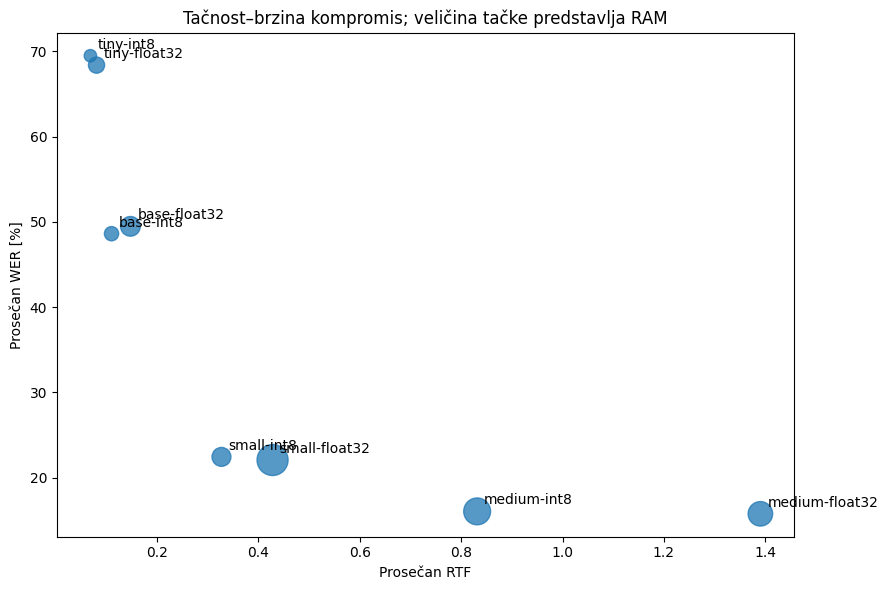

In [18]:
# ============================================================
# GRAFIK — WER VS RTF, VELIČINA TAČKE ~ RAM
# ============================================================

plt.figure(figsize=(9, 6))

ram = tabela_score["RAM_model_MB"].astype(float)
sizes = 80 + 420 * (ram - ram.min()) / max(ram.max() - ram.min(), 1e-9)

plt.scatter(
    tabela_score["Prosecan_RTF"],
    tabela_score["Prosecan_WER"],
    s=sizes,
    alpha=0.75
)

for _, r in tabela_score.iterrows():
    plt.annotate(
        r["Konfiguracija"],
        (r["Prosecan_RTF"], r["Prosecan_WER"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Prosečan RTF")
plt.ylabel("Prosečan WER [%]")
plt.title("Tačnost–brzina kompromis; veličina tačke predstavlja RAM")
plt.tight_layout()
plt.show()


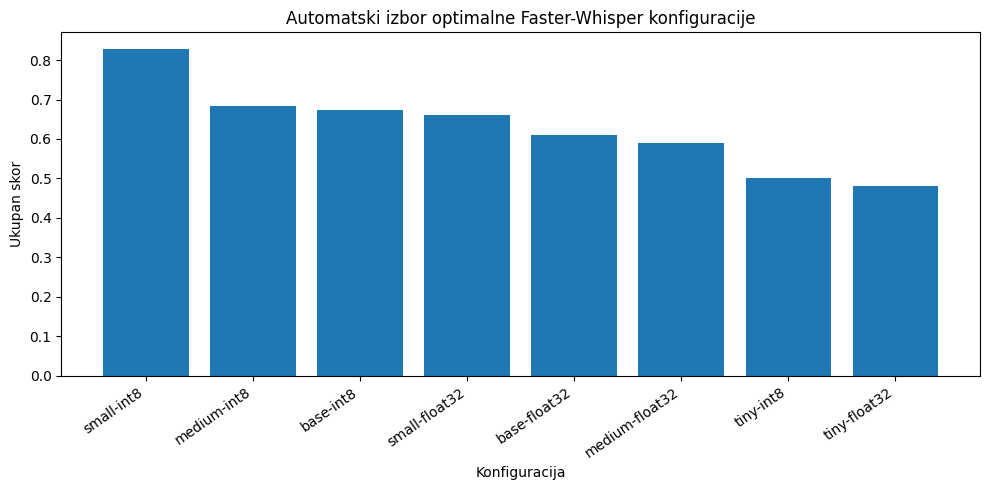

In [19]:
# ============================================================
# GRAFIK — UKUPAN SKOR
# ============================================================

plot_df = tabela_score.sort_values("Ukupan_skor", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Konfiguracija"], plot_df["Ukupan_skor"])
plt.xlabel("Konfiguracija")
plt.ylabel("Ukupan skor")
plt.title("Automatski izbor optimalne Faster-Whisper konfiguracije")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


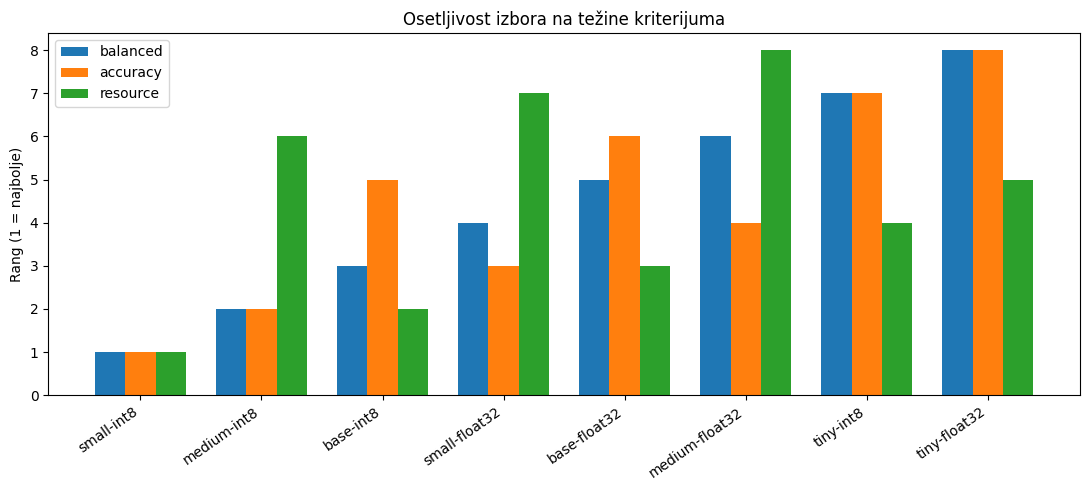

In [20]:
# ============================================================
# GRAFIK — RANG PO RAZLIČITIM PROFILIMA
# ============================================================

profil_plot = sensitivity[
    ["Konfiguracija", "Rang_balanced", "Rang_accuracy", "Rang_resource"]
].copy()

x = np.arange(len(profil_plot))
w = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - w, profil_plot["Rang_balanced"], width=w, label="balanced")
plt.bar(x, profil_plot["Rang_accuracy"], width=w, label="accuracy")
plt.bar(x + w, profil_plot["Rang_resource"], width=w, label="resource")

plt.xticks(x, profil_plot["Konfiguracija"], rotation=35, ha="right")
plt.ylabel("Rang (1 = najbolje)")
plt.title("Osetljivost izbora na težine kriterijuma")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

df05.to_csv(
    OUT_DIR / "08_svi_rezultati_sa_wer.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_modela.to_csv(
    OUT_DIR / "08_agregat_po_konfiguraciji.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_score.to_csv(
    OUT_DIR / "08_rang_lista_balanced.csv",
    index=False,
    encoding="utf-8-sig"
)

sensitivity.to_csv(
    OUT_DIR / "08_sensitivity_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_profil.to_csv(
    OUT_DIR / "08_konacni_preporuceni_profil.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati sačuvani u:")
print(OUT_DIR)


Rezultati sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\08_automatski_izbor_optimalne_konfiguracije


## Zaključak eksperimenta

Integracijom rezultata prethodnih eksperimenata formiran je postupak za automatski izbor Faster-Whisper konfiguracije prema unapred definisanim kriterijumima tačnosti, brzine i memorijske zahtevnosti.

Na osnovu svih **40 prirodnih srpskih audio zapisa**, odnosno **320 prethodno izvršenih transkripcija**, kao najbolje rangirana konfiguracija prema balansiranom skoru izabrana je:

**Faster-Whisper small + INT8**

sa sledećim rezultatima:

* prosečan WER: **22,43%**,
* corpus WER: **22,22%**,
* prosečan RTF: **0,3272**,
* RAM metrika: **263,80 MB**,
* ukupan skor: **0,8289**.

`small-int8` je istovremeno Pareto-optimalna konfiguracija i zauzima prvo mesto u sva tri analizirana scenarija težina, što pokazuje da je izbor stabilan u okviru definisanih kriterijuma.

Rezultati zasebnih eksperimenata zatim se koriste za određivanje ostalih parametara sistema. Na osnovu tih eksperimenata formiran je sledeći automatski preporučen profil:

* **model:** small,
* **kvantizacija:** INT8,
* **uređaj:** CPU,
* **jezik:** srpski,
* **beam size:** 5,
* **VAD:** uključen,
* **streaming chunk:** 10 s.

Važno je naglasiti da ovaj profil ne predstavlja univerzalno najbolju Faster-Whisper konfiguraciju. Optimalnost je definisana u okviru korišćenog CPU okruženja, prirodnog srpskog benchmark skupa, testiranih konfiguracija i izabranih kriterijuma.

Takođe, parametri `beam_size`, VAD i veličina streaming chunk-a nisu uključeni u isti matematički skor sa modelom i kvantizacijom, jer potiču iz zasebnih eksperimenata izvedenih na različitim podskupovima. Oni predstavljaju dodatne preporuke zasnovane na rezultatima odgovarajućih kontrolisanih eksperimenata.

Zbog toga glavni rezultat ovog doprinosa nije tvrdnja da postoji jedna univerzalno najbolja konfiguracija, već demonstracija **reproduktivnog višekriterijumskog postupka kojim se optimalna konfiguracija može automatski odabrati za konkretan skup zahteva i eksperimentalne uslove**.
